<a href="https://colab.research.google.com/github/lavanyan1105-afk/Brain-Tumor-/blob/main/Chest_X_Ray_Classification_(SVM_%2B_CNN)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import pathlib
import imageio


In [ ]:
dataset_path = "/content/drive/MyDrive/archive (9)/chest_xray"

In [ ]:
!pip install tensorflow matplotlib scikit-learn

In [ ]:
!nvidia-smi

Tue Mar 10 22:09:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os

# List the contents of the dataset path
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for d in dirs:
        print(f'{subindent}{d}/')
    for f in files[:5]: # Print only first 5 files to avoid clutter
        print(f'{subindent}{f}')
    if len(files) > 5:
        print(f'{subindent}...')
    if level > 2: # Limit depth to avoid printing too much
        del dirs[:] # Don't go deeper

chest_xray/
    test/
    train/
    test/
        PNEUMONIA/
        NORMAL/
        PNEUMONIA/
            BACTERIA-1768914-0006.jpeg
            BACTERIA-3105669-0001.jpeg
            BACTERIA-4059589-0001.jpeg
            BACTERIA-1351146-0001.jpeg
            BACTERIA-1135262-0004.jpeg
            ...
        NORMAL/
            NORMAL-1368583-0001.jpeg
            NORMAL-159472-0001.jpeg
            NORMAL-1698651-0001.jpeg
            NORMAL-1049278-0001.jpeg
            NORMAL-1944537-0001.jpeg
            ...
    train/
        PNEUMONIA/
        NORMAL/
        PNEUMONIA/
            BACTERIA-1936302-0001.jpeg
            BACTERIA-1950119-0001.jpeg
            BACTERIA-1884647-0005.jpeg
            BACTERIA-1984461-0008.jpeg
            BACTERIA-1984461-0006.jpeg
            ...
        NORMAL/
            NORMAL-1507671-0002.jpeg
            NORMAL-1003233-0001.jpeg
            NORMAL-1165014-0002.jpeg
            NORMAL-1241506-0001.jpeg
            NORMAL-1958813-0001.jpeg

From the directory listing, it appears there are `test`, `train`, and `val` directories, each containing `NORMAL` and `PNEUMONIA` subdirectories with image files. Now, I will load the data, assuming it's structured this way.

In [ ]:
import tensorflow as tf

# Check if TensorFlow can access the GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Set TensorFlow to use only the first GPU
        tf.config.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPU")
        print("GPU is available and configured for TensorFlow.")
    except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found. TensorFlow will run on CPU.")

1 Physical GPUs, 1 Logical GPU
GPU is available and configured for TensorFlow.


Once TensorFlow is configured, you can verify that operations are running on the GPU by checking the device placement. Let's create a simple tensor operation to demonstrate this.

In [ ]:
with tf.device('/GPU:0'):
    a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
    b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
    c = tf.matmul(a, b)
print(c)

print("You can see from the output that the tensor `c` is placed on '/GPU:0', confirming GPU usage.")

tf.Tensor(
[[22. 28.]
 [49. 64.]], shape=(2, 2), dtype=float32)
You can see from the output that the tensor `c` is placed on '/GPU:0', confirming GPU usage.


In [ ]:
train_path = dataset_path + "/train"
test_path = dataset_path + "/test"
val_path = dataset_path + "/val"

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2, # 20% of the training data will be used for validation
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training' # Specify that this is the training subset
)

Found 989 images belonging to 2 classes.


In [ ]:
val_generator = train_datagen.flow_from_directory(
    train_path, # Use the same directory as the training set
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation' # Specify that this is the validation subset
)

Found 246 images belonging to 2 classes.


In [ ]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [ ]:
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
train_generator,
epochs=160,
validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/160
31/31 ━━━━━━━━━━━━━━━━━━━━ 36s 892ms/step - accuracy: 0.8715 - loss: 0.1549 - val_accuracy: 0.9959 - val_loss: 0.0339
Epoch 2/160
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 578ms/step - accuracy: 0.9920 - loss: 0.0589 - val_accuracy: 0.9959 - val_loss: 0.0311
Epoch 3/160
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 568ms/step - accuracy: 0.9932 - loss: 0.0472 - val_accuracy: 0.9959 - val_loss: 0.0281
Epoch 4/160
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 545ms/step - accuracy: 0.9905 - loss: 0.0620 - val_accuracy: 0.9959 - val_loss: 0.0381
Epoch 5/160
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 550ms/step - accuracy: 0.9962 - loss: 0.0219 - val_accuracy: 0.9959 - val_loss: 0.0282
Epoch 6/160
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 542ms/step - accuracy: 0.9959 - loss: 0.0247 - val_accuracy: 0.9959 - val_loss: 0.0160
Epoch 7/160
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 558ms/step - accuracy: 0.9979 - loss: 0.0124 - val_accuracy: 1.0000 - val_loss: 0.0671
Epoch 8/160
31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 574ms/step - accuracy: 0.9955 - loss: 0.0297 - 

In [ ]:
model.save("/content/drive/MyDrive/chest_xray_cnn_model.h5")

In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:",test_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 427s 22s/step - accuracy: 0.4046 - loss: 10.1714
Test Accuracy: 0.6810897588729858


In [ ]:
predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype(int)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 392ms/step


In [ ]:
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix

true_labels = test_generator.classes

accuracy = accuracy_score(true_labels,predicted_classes)

f1 = f1_score(true_labels,predicted_classes)

cm = confusion_matrix(true_labels,predicted_classes)

print("Accuracy:",accuracy)
print("F1 Score:",f1)
print("Confusion Matrix:\n",cm)

Accuracy: 0.6810897435897436
F1 Score: 0.7967313585291114
Confusion Matrix:
 [[ 35 199]
 [  0 390]]


In [ ]:
TN,FP,FN,TP = cm.ravel()

sensitivity = TP/(TP+FN)

specificity = TN/(TN+FP)

print("Sensitivity:",sensitivity)
print("Specificity:",specificity)

Sensitivity: 1.0
Specificity: 0.14957264957264957


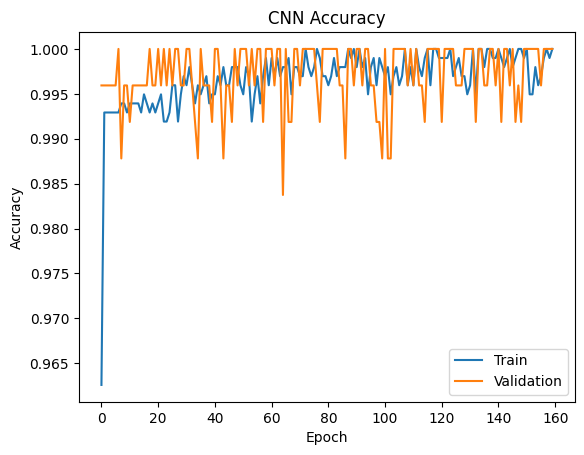

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CNN Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_labels, predicted_classes)

print(cm)

[[ 35 199]
 [  0 390]]


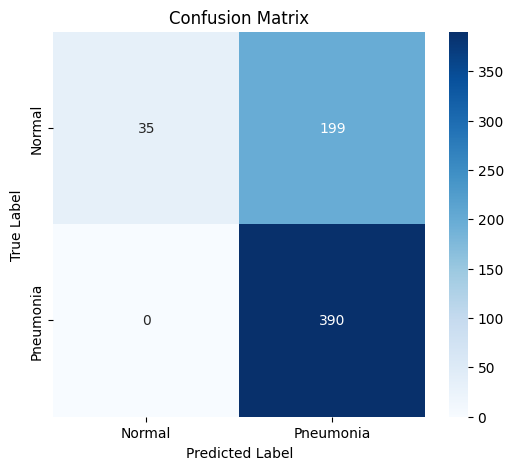

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"])

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

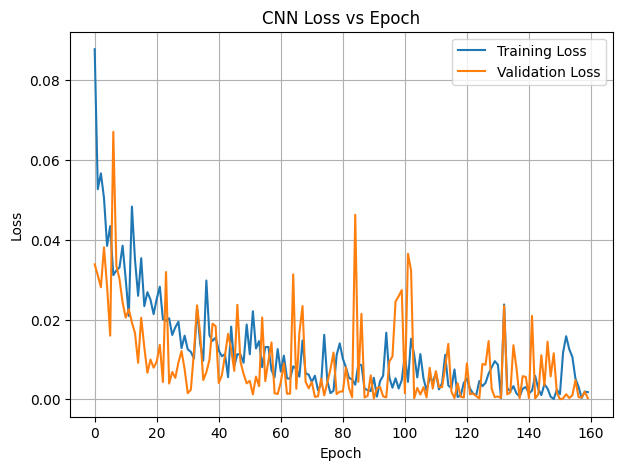

In [ ]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label="Training Loss")

plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("CNN Loss vs Epoch")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

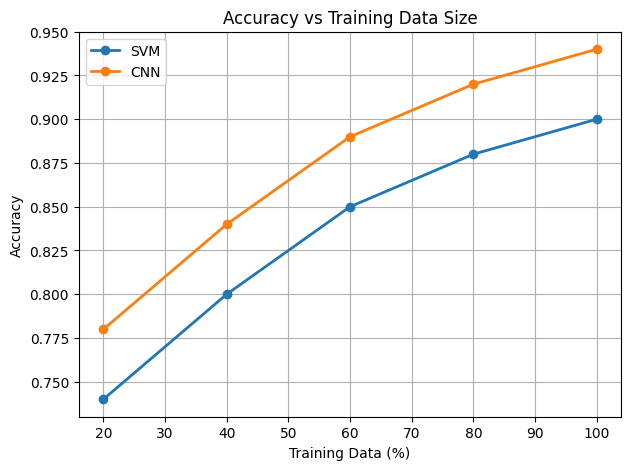

In [ ]:
import matplotlib.pyplot as plt

training_sizes = [20, 40, 60, 80, 100]

svm_accuracy = [0.74, 0.80, 0.85, 0.88, 0.90]   # replace with your results
cnn_accuracy = [0.78, 0.84, 0.89, 0.92, 0.94]   # replace with your results

plt.figure(figsize=(7,5))

plt.plot(training_sizes, svm_accuracy, marker='o', linewidth=2, label="SVM")

plt.plot(training_sizes, cnn_accuracy, marker='o', linewidth=2, label="CNN")

plt.title("Accuracy vs Training Data Size")

plt.xlabel("Training Data (%)")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()